(matplotlib)=
```{raw} jupyter
<div id="qe-notebook-header" align="right" style="text-align:right;">
        <a href="https://quantecon.org/" title="quantecon.org">
                <img style="width:250px;display:inline;" width="250px" src="https://assets.quantecon.org/img/qe-menubar-logo.svg" alt="QuantEcon">
        </a>
</div>
```

# {index}`Matplotlib <single: Matplotlib>`

```{index} single: Python; Matplotlib
```

## مروری کلی

ما تاکنون با استفاده از [Matplotlib](https://matplotlib.org/) تعداد قابل توجهی نمودار در این سخنرانی‌ها تولید کرده‌ایم.

Matplotlib یک کتابخانه گرافیکی عالی است که برای محاسبات علمی طراحی شده و دارای ویژگی‌های زیر است:

* نمودارهای دو بعدی و سه بعدی با کیفیت بالا
* خروجی در تمام فرمت‌های معمول (PDF، PNG و غیره)
* یکپارچگی با LaTeX
* کنترل دقیق بر تمام جنبه‌های نمایش
* انیمیشن و غیره

### شخصیت دوگانه Matplotlib

Matplotlib در این زمینه غیرمعمول است که دو رابط مختلف برای ترسیم نمودار ارائه می‌دهد.

یکی API ساده به سبک MATLAB (رابط برنامه‌نویسی کاربردی) است که برای کمک به مهاجران MATLAB برای یافتن خانه‌ای آماده نوشته شده است.

دیگری یک API شی‌گرا و "پایتونی‌تر" است.

به دلایلی که در زیر توضیح داده شده است، توصیه می‌کنیم از API دوم استفاده کنید.

اما ابتدا، بیایید در مورد تفاوت آن‌ها بحث کنیم.

## APIها

```{index} single: Matplotlib; Simple API
```

### API به سبک MATLAB

در اینجا نوعی مثال ساده است که ممکن است در آموزش‌های مقدماتی بیابید

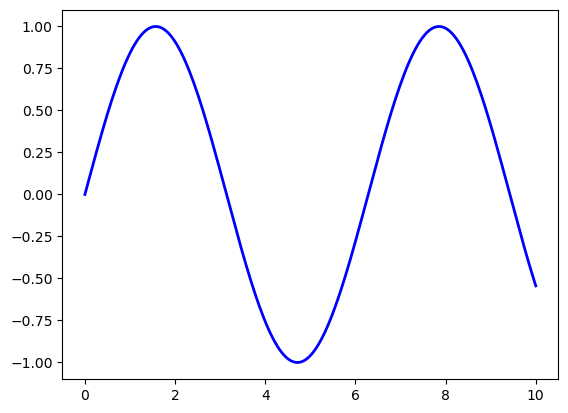

In [1]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 200)
y = np.sin(x)

plt.plot(x, y, 'b-', linewidth=2)
plt.show()

این ساده و راحت است، اما تا حدودی محدود و غیرپایتونی نیز هست.

به عنوان مثال، در فراخوانی‌های تابع، اشیاء زیادی ایجاد و منتقل می‌شوند بدون اینکه خود را به برنامه‌نویس معرفی کنند.

برنامه‌نویسان پایتون تمایل دارند سبک صریح‌تری از برنامه‌نویسی را ترجیح دهند (دستور `import this` را در یک بلوک کد اجرا کنید و به خط دوم نگاه کنید).

این ما را به جایگزین، یعنی API شی‌گرای Matplotlib هدایت می‌کند.

### API شی‌گرا

در اینجا کد مربوط به نمودار قبلی با استفاده از API شی‌گرا آمده است

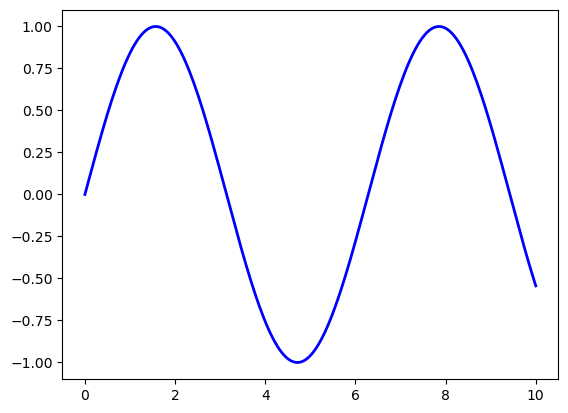

In [2]:
fig, ax = plt.subplots()
ax.plot(x, y, 'b-', linewidth=2)
plt.show()

در اینجا فراخوانی `fig, ax = plt.subplots()` یک جفت برمی‌گرداند، که در آن

* `fig` یک نمونه از `Figure` است --- مانند یک بوم خالی.
* `ax` یک نمونه از `AxesSubplot` است --- آن را به عنوان یک قاب برای ترسیم در نظر بگیرید.

تابع `plot()` در واقع یک متد از `ax` است.

در حالی که تایپ کردن کمی بیشتر است، استفاده صریح‌تر از اشیاء کنترل بهتری به ما می‌دهد.

این موضوع با ادامه کار واضح‌تر خواهد شد.

### تنظیمات ریز

در اینجا ما خط را به قرمز تغییر داده و یک راهنما اضافه کرده‌ایم

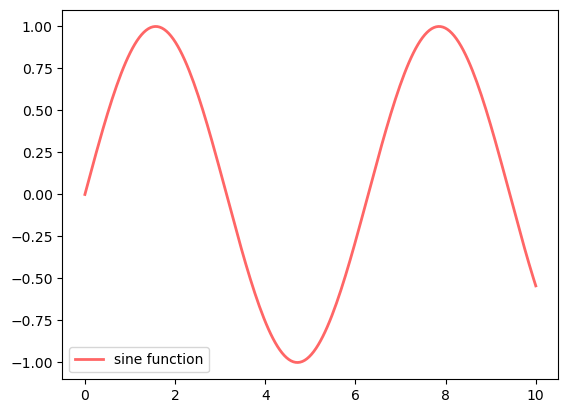

In [3]:
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend()
plt.show()

ما همچنین از `alpha` استفاده کرده‌ایم تا خط را کمی شفاف کنیم --- که باعث می‌شود نرم‌تر به نظر برسد.

موقعیت راهنما را می‌توان با جایگزینی `ax.legend()` با `ax.legend(loc='upper center')` تغییر داد.

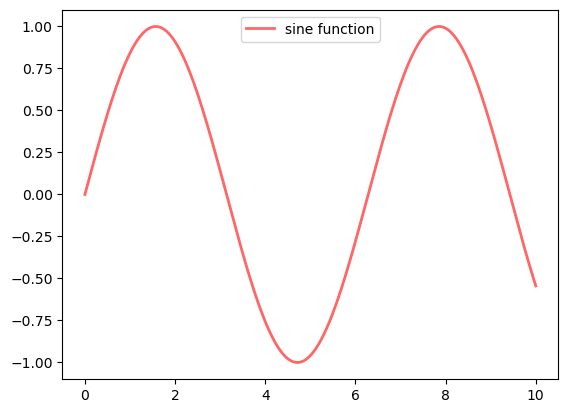

In [4]:
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend(loc='upper center')
plt.show()

اگر همه چیز به درستی پیکربندی شده باشد، اضافه کردن LaTeX بسیار ساده است

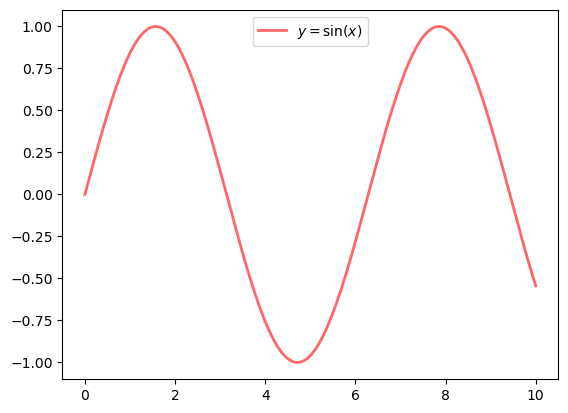

In [5]:
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label=r'$y=\sin(x)$', alpha=0.6)
ax.legend(loc='upper center')
plt.show()

کنترل علامت‌ها، افزودن عناوین و غیره نیز ساده است

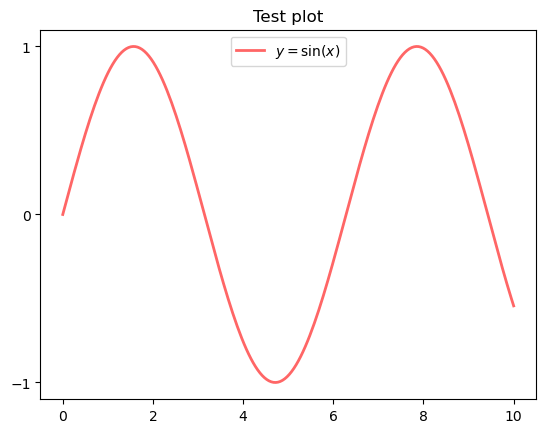

In [6]:
fig, ax = plt.subplots()
ax.plot(x, y, 'r-', linewidth=2, label=r'$y=\sin(x)$', alpha=0.6)
ax.legend(loc='upper center')
ax.set_yticks([-1, 0, 1])
ax.set_title('Test plot')
plt.show()

## ویژگی‌های بیشتر

Matplotlib مجموعه عظیمی از توابع و ویژگی‌ها دارد که می‌توانید در طول زمان و با نیاز به آن‌ها، آن‌ها را کشف کنید.

ما فقط چند مورد را ذکر می‌کنیم.

### نمودارهای چندگانه روی یک محور

```{index} single: Matplotlib; Multiple Plots on One Axis
```

تولید نمودارهای چندگانه روی یک محور بسیار ساده است.

در اینجا مثالی است که به طور تصادفی سه چگالی نرمال تولید می‌کند و برچسبی با میانگین آن‌ها اضافه می‌کند

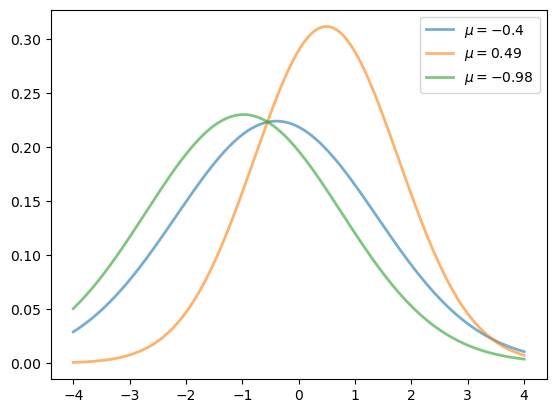

In [7]:
from scipy.stats import norm
from random import uniform

fig, ax = plt.subplots()
x = np.linspace(-4, 4, 150)
for i in range(3):
    m, s = uniform(-1, 1), uniform(1, 2)
    y = norm.pdf(x, loc=m, scale=s)
    current_label = rf'$\mu = {m:.2}$'
    ax.plot(x, y, linewidth=2, alpha=0.6, label=current_label)
ax.legend()
plt.show()

### زیرنمودارهای چندگانه

```{index} single: Matplotlib; Subplots
```

گاهی اوقات می‌خواهیم زیرنمودارهای چندگانه در یک شکل داشته باشیم.

در اینجا مثالی است که ۶ هیستوگرام تولید می‌کند

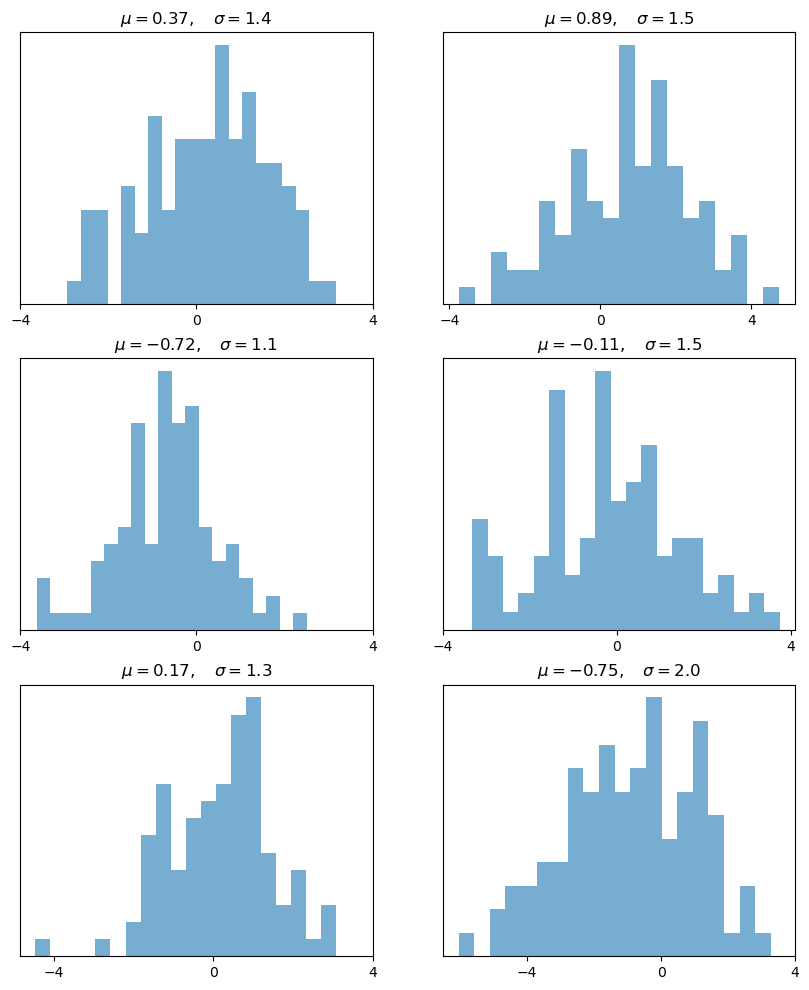

In [8]:
num_rows, num_cols = 3, 2
fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 12))
for i in range(num_rows):
    for j in range(num_cols):
        m, s = uniform(-1, 1), uniform(1, 2)
        x = norm.rvs(loc=m, scale=s, size=100)
        axes[i, j].hist(x, alpha=0.6, bins=20)
        t = rf'$\mu = {m:.2}, \quad \sigma = {s:.2}$'
        axes[i, j].set(title=t, xticks=[-4, 0, 4], yticks=[])
plt.show()

### نمودارهای سه بعدی

```{index} single: Matplotlib; 3D Plots
```

Matplotlib کار خوبی در ترسیم نمودارهای سه بعدی انجام می‌دهد --- در اینجا یک مثال آورده شده است

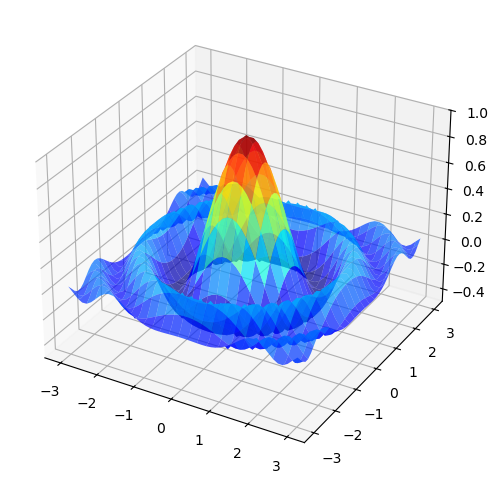

In [9]:
from mpl_toolkits.mplot3d.axes3d import Axes3D
from matplotlib import cm


def f(x, y):
    return np.cos(x**2 + y**2) / (1 + x**2 + y**2)

xgrid = np.linspace(-3, 3, 50)
ygrid = xgrid
x, y = np.meshgrid(xgrid, ygrid)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x,
                y,
                f(x, y),
                rstride=2, cstride=2,
                cmap=cm.jet,
                alpha=0.7,
                linewidth=0.25)
ax.set_zlim(-0.5, 1.0)
plt.show()

### یک تابع سفارشی‌سازی

شاید مجموعه‌ای از سفارشی‌سازی‌ها را پیدا کنید که به طور منظم از آن‌ها استفاده می‌کنید.

فرض کنید معمولاً ترجیح می‌دهیم محورهای ما از مبدأ عبور کنند و یک شبکه داشته باشند.

در اینجا یک مثال خوب از [Matthew Doty](https://github.com/xcthulhu) وجود دارد که نشان می‌دهد چگونه API شی‌گرا می‌تواند برای ساخت یک تابع سفارشی `subplots` که این تغییرات را پیاده‌سازی می‌کند، استفاده شود.

با دقت کد را بخوانید و ببینید آیا می‌توانید دنبال کنید که چه اتفاقی می‌افتد

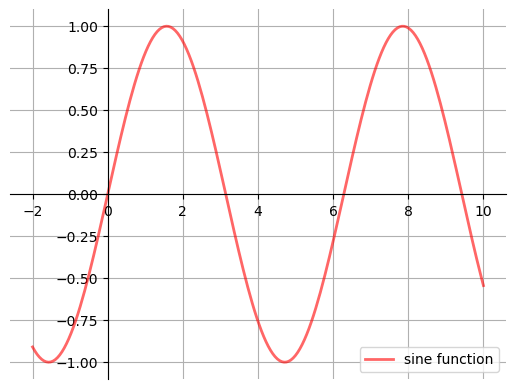

In [10]:
def subplots():
    "Custom subplots with axes through the origin"
    fig, ax = plt.subplots()

    # Set the axes through the origin
    for spine in ['left', 'bottom']:
        ax.spines[spine].set_position('zero')
    for spine in ['right', 'top']:
        ax.spines[spine].set_color('none')

    ax.grid()
    return fig, ax


fig, ax = subplots()  # Call the local version, not plt.subplots()
x = np.linspace(-2, 10, 200)
y = np.sin(x)
ax.plot(x, y, 'r-', linewidth=2, label='sine function', alpha=0.6)
ax.legend(loc='lower right')
plt.show()

تابع سفارشی `subplots`

1. تابع استاندارد `plt.subplots` را به صورت داخلی فراخوانی می‌کند تا جفت `fig, ax` را تولید کند،
1. سفارشی‌سازی‌های مورد نظر را روی `ax` انجام می‌دهد، و
1. جفت `fig, ax` را به کد فراخوان‌کننده برمی‌گرداند.

### برگه‌های سبک

یکی دیگر از ویژگی‌های مفید در Matplotlib، [برگه‌های سبک](https://matplotlib.org/stable/gallery/style_sheets/style_sheets_reference.html) است.

ما می‌توانیم از برگه‌های سبک برای ایجاد نمودارهایی با سبک‌های یکنواخت استفاده کنیم.

می‌توانیم لیستی از سبک‌های موجود را با چاپ ویژگی `plt.style.available` پیدا کنیم

In [11]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


اکنون می‌توانیم از متد `plt.style.use()` برای تنظیم برگه سبک استفاده کنیم.

بیایید تابعی بنویسیم که نام یک برگه سبک را می‌گیرد و نمودارهای مختلف را با آن سبک ترسیم می‌کند

In [12]:
def draw_graphs(style='default'):

    # Setting a style sheet
    plt.style.use(style)

    fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(10, 3))
    x = np.linspace(-13, 13, 150)

    # Set seed values to replicate results of random draws
    np.random.seed(9)

    for i in range(3):

        # Draw mean and standard deviation from uniform distributions
        m, s = np.random.uniform(-8, 8), np.random.uniform(2, 2.5)

        # Generate a normal density plot
        y = norm.pdf(x, loc=m, scale=s)
        axes[0].plot(x, y, linewidth=3, alpha=0.7)

        # Create a scatter plot with random X and Y values 
        # from normal distributions
        rnormX = norm.rvs(loc=m, scale=s, size=150)
        rnormY = norm.rvs(loc=m, scale=s, size=150)
        axes[1].plot(rnormX, rnormY, ls='none', marker='o', alpha=0.7)

        # Create a histogram with random X values
        axes[2].hist(rnormX, alpha=0.7)

        # and a line graph with random Y values
        axes[3].plot(x, rnormY, linewidth=2, alpha=0.7)

    style_name = style.split('-')[0]
    plt.suptitle(f'Style: {style_name}', fontsize=13)
    plt.show()


بیایید ببینیم برخی از سبک‌ها چگونه به نظر می‌رسند.

ابتدا، نمودارها را با برگه سبک `seaborn` ترسیم می‌کنیم

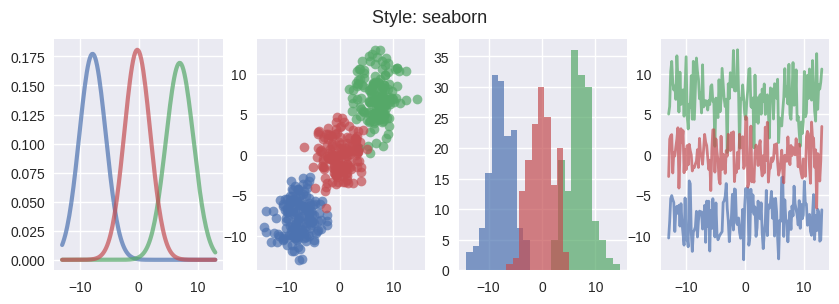

In [13]:
draw_graphs(style='seaborn-v0_8')

می‌توانیم از `grayscale` برای حذف رنگ‌ها در نمودارها استفاده کنیم

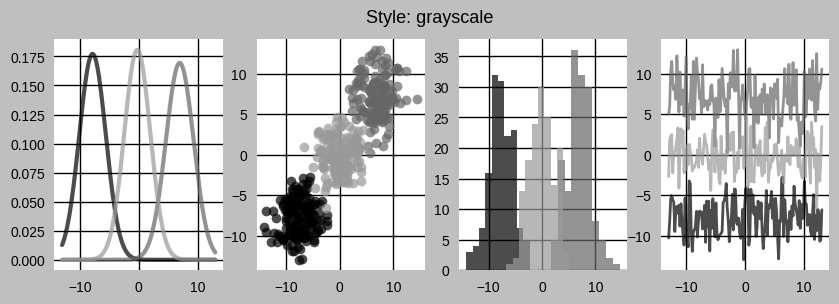

In [14]:
draw_graphs(style='grayscale')

در اینجا نشان داده می‌شود که `ggplot` چگونه به نظر می‌رسد

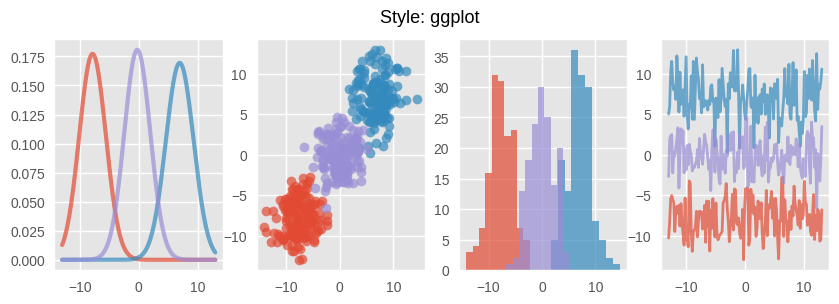

In [15]:
draw_graphs(style='ggplot')

همچنین می‌توانیم از سبک `dark_background` استفاده کنیم

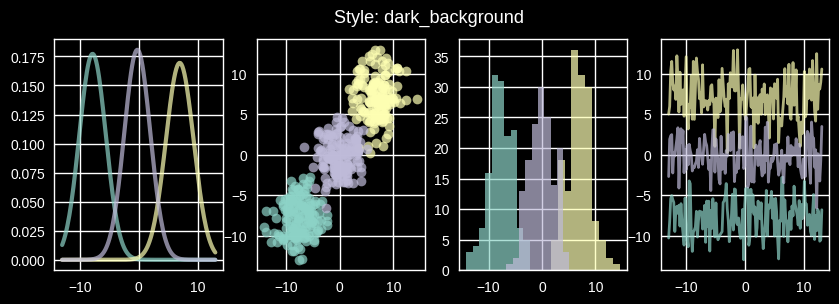

In [16]:
draw_graphs(style='dark_background')

می‌توانید از این تابع برای آزمایش سبک‌های دیگر در لیست استفاده کنید.

اگر علاقه‌مند هستید، حتی می‌توانید برگه‌های سبک خود را ایجاد کنید.

پارامترهای برگه‌های سبک شما در یک متغیر شبه دیکشنری به نام `plt.rcParams` ذخیره می‌شوند

In [17]:
print(plt.rcParams.keys())

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': True,
          'axes.edgecolor': 'white',
          'axes.facecolor': 'black',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': True,
          'axes.grid.axis': 'both

پارامترهای زیادی وجود دارد که می‌توانید برای برگه‌های سبک خود تنظیم کنید.

پارامترها را برای برگه سبک خود با روش‌های زیر تنظیم کنید:

1. ایجاد [فایل `matplotlibrc`](https://matplotlib.org/stable/users/explain/customizing.html) خود، یا
2. به‌روزرسانی مقادیر ذخیره شده در متغیر شبه دیکشنری `plt.rcParams`

بیایید سبک خطوط چگالی روی هم قرار گرفته خود را با استفاده از روش دوم تغییر دهیم

In [18]:
from cycler import cycler

# set to the default style sheet
plt.style.use('default')

# You can update single values using keys:

# Set the font style to italic
plt.rcParams['font.style'] = 'italic'

# Update linewidth
plt.rcParams['lines.linewidth'] = 2


# You can also update many values at once using the update() method:

parameters = {

    # Change default figure size
    'figure.figsize': (5, 4),

    # Add horizontal grid lines
    'axes.grid': True,
    'axes.grid.axis': 'y',

    # Update colors for density lines
    'axes.prop_cycle': cycler('color', 
                            ['dimgray', 'slategrey', 'darkgray'])
}

plt.rcParams.update(parameters)



```{note} 

این تنظیمات `سراسری` هستند.

هر نمودار تولید شده پس از تغییر پارامترها در `.rcParams` تحت تأثیر این تنظیم قرار می‌گیرد.

```

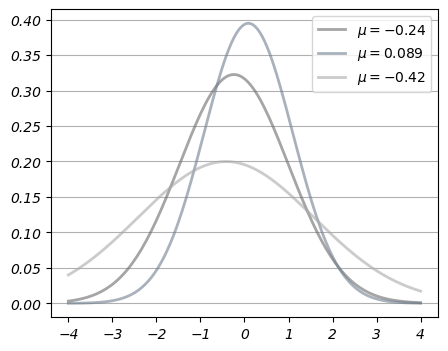

In [19]:
fig, ax = plt.subplots()
x = np.linspace(-4, 4, 150)
for i in range(3):
    m, s = uniform(-1, 1), uniform(1, 2)
    y = norm.pdf(x, loc=m, scale=s)
    current_label = rf'$\mu = {m:.2}$'
    ax.plot(x, y, linewidth=2, alpha=0.6, label=current_label)
ax.legend()
plt.show()

دوباره برگه سبک `default` را اعمال کنید تا سبک خود را به حالت پیش‌فرض برگردانید

In [20]:
plt.style.use('default')

# Reset default figure size
plt.rcParams['figure.figsize'] = (10, 6)


## مطالعه بیشتر

* [گالری Matplotlib](https://matplotlib.org/stable/gallery/index.html) مثال‌های زیادی ارائه می‌دهد.
* یک [آموزش خوب Matplotlib](https://scipy-lectures.org/intro/matplotlib/index.html) توسط Nicolas Rougier، Mike Muller و Gael Varoquaux.
* [mpltools](https://tonysyu.github.io/mpltools/index.html) امکان تعویض آسان بین سبک‌های نمودار را فراهم می‌کند.
* [Seaborn](https://github.com/mwaskom/seaborn) نمودارهای آماری رایج را در Matplotlib تسهیل می‌کند.

## تمرین‌ها

```{exercise-start}
:label: mpl_ex1
```

تابع زیر را ترسیم کنید

$$
f(x) = \cos(\pi \theta x) \exp(-x)
$$

روی بازه $[0, 5]$ برای هر $\theta$ در `np.linspace(0, 2, 10)`.

تمام منحنی‌ها را در یک شکل قرار دهید.

خروجی باید شبیه این باشد

```{image} /_static/lecture_specific/matplotlib/matplotlib_ex1.png
:scale: 130
:align: center
```

```{exercise-end}
```

```{solution-start} mpl_ex1
:class: dropdown
```

در اینجا یک راه‌حل آمده است

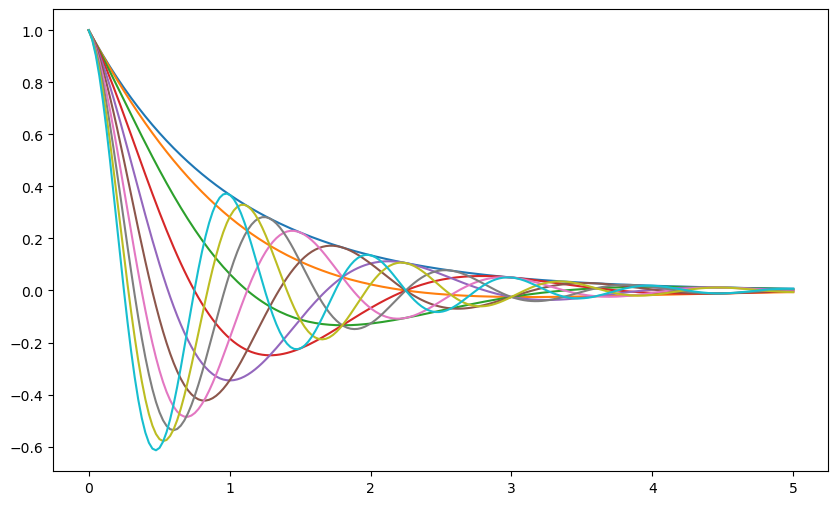

In [21]:
def f(x, θ):
    return np.cos(np.pi * θ * x ) * np.exp(- x)

θ_vals = np.linspace(0, 2, 10)
x = np.linspace(0, 5, 200)
fig, ax = plt.subplots()

for θ in θ_vals:
    ax.plot(x, f(x, θ))

plt.show()

```{solution-end}
```